In [2]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

# plt.style.use('default')
sns.set_theme()

In [3]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

You are using a GLFW raw input patch. This is not the official GLFW library.


/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/bin/../lib/libjpeg.9.dylib' (no su

In [4]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [5]:
domain = "quadruped"

In [6]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [7]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [8]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/step"] = steps
    temp["eval/episode_reward"] = avg_episode_reward

    if "attention" in run.config["agent_name"]:
        #attention 1
        # attention_6_history_1 = run.scan_history(keys=["train/attention_distribution1_u_6_mean"])
        # attention_6_1 = [row["train/attention_distribution1_u_6_mean"] for row in attention_6_history_1]
        #
        # attention_5_history_1 = run.scan_history(keys=["train/attention_distribution1_u_5_mean"])
        # attention_5_1 = [row["train/attention_distribution1_u_5_mean"] for row in attention_5_history_1]

        # attention_4_history_1 = run.scan_history(keys=["train/attention_distribution1_u_4_mean"])
        # attention_4_1 = [row["train/attention_distribution1_u_4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_distribution1_u_3_mean"])
        attention_3_1 = [row["train/attention_distribution1_u_3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_distribution1_u_2_mean"])
        attention_2_1 = [row["train/attention_distribution1_u_2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_distribution1_u_1_mean"])
        attention_1_1 = [row["train/attention_distribution1_u_1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_distribution1_u_0_mean"])
        attention_0_1 = [row["train/attention_distribution1_u_0_mean"] for row in attention_0_history_1]

        #attention 2
        # attention_6_history_2 = run.scan_history(keys=["train/attention_distribution2_u_6_mean"])
        # attention_6_2 = [row["train/attention_distribution2_u_6_mean"] for row in attention_6_history_2]
        #
        # attention_5_history_2 = run.scan_history(keys=["train/attention_distribution2_u_5_mean"])
        # attention_5_2 = [row["train/attention_distribution2_u_5_mean"] for row in attention_5_history_2]

        # attention_4_history_2 = run.scan_history(keys=["train/attention_distribution2_u_4_mean"])
        # attention_4_2 = [row["train/attention_distribution2_u_4_mean"] for row in attention_4_history_2]

        attention_3_history_2 = run.scan_history(keys=["train/attention_distribution2_u_3_mean"])
        attention_3_2 = [row["train/attention_distribution2_u_3_mean"] for row in attention_3_history_2]

        attention_2_history_2 = run.scan_history(keys=["train/attention_distribution2_u_2_mean"])
        attention_2_2 = [row["train/attention_distribution2_u_2_mean"] for row in attention_2_history_2]

        attention_1_history_2 = run.scan_history(keys=["train/attention_distribution2_u_1_mean"])
        attention_1_2 = [row["train/attention_distribution2_u_1_mean"] for row in attention_1_history_2]

        attention_0_history_2 = run.scan_history(keys=["train/attention_distribution2_u_0_mean"])
        attention_0_2 = [row["train/attention_distribution2_u_0_mean"] for row in attention_0_history_2]

        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        attention_3_1.insert(0, 0)
        attention_2_1.insert(0, 0)
        attention_1_1.insert(0, 0)
        attention_0_1.insert(0, 0)

        # attention_6_2.insert(0, 0)
        # attention_5_2.insert(0, 0)
        # attention_4_2.insert(0, 0)
        attention_3_2.insert(0, 0)
        attention_2_2.insert(0, 0)
        attention_1_2.insert(0, 0)
        attention_0_2.insert(0, 0)

        # temp["train/attention_distribution1_u_6_mean"] = attention_6_1
        # temp["train/attention_distribution1_u_5_mean"] = attention_5_1
        # temp["train/attention_distribution1_u_4_mean"] = attention_4_1
        temp["train/attention_distribution1_u_3_mean"] = attention_3_1
        temp["train/attention_distribution1_u_2_mean"] = attention_2_1
        temp["train/attention_distribution1_u_1_mean"] = attention_1_1
        temp["train/attention_distribution1_u_0_mean"] = attention_0_1

        # temp["train/attention_distribution2_u_6_mean"] = attention_6_2
        # temp["train/attention_distribution2_u_5_mean"] = attention_5_2
        # temp["train/attention_distribution2_u_4_mean"] = attention_4_2
        temp["train/attention_distribution2_u_3_mean"] = attention_3_2
        temp["train/attention_distribution2_u_2_mean"] = attention_2_2
        temp["train/attention_distribution2_u_1_mean"] = attention_1_2
        temp["train/attention_distribution2_u_0_mean"] = attention_0_2

    else:
        zeros_list = [0] * len(steps)
        # temp["train/attention_distribution1_u_6_mean"] = zeros_list
        # temp["train/attention_distribution1_u_5_mean"] = zeros_list
        # temp["train/attention_distribution1_u_4_mean"] = zeros_list
        temp["train/attention_distribution1_u_3_mean"] = zeros_list
        temp["train/attention_distribution1_u_2_mean"] = zeros_list
        temp["train/attention_distribution1_u_1_mean"] = zeros_list
        temp["train/attention_distribution1_u_0_mean"] = zeros_list

        # temp["train/attention_distribution2_u_6_mean"] = zeros_list
        # temp["train/attention_distribution2_u_5_mean"] = zeros_list
        # temp["train/attention_distribution2_u_4_mean"] = zeros_list
        temp["train/attention_distribution2_u_3_mean"] = zeros_list
        temp["train/attention_distribution2_u_2_mean"] = zeros_list
        temp["train/attention_distribution2_u_1_mean"] = zeros_list
        temp["train/attention_distribution2_u_0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_distribution1_u_0_mean"]))

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 541
idx: 0
idx: 10
idx: 20
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
idx: 30
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
ddpg
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
idx: 40
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
len attention_0_1:  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_rewar

In [9]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [10]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [11]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [21]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['SF' 'TD3' 'SF + SC (Ours)' 'TD3 + SC' 'TD3 + EWC' 'SF + EWC'
 'SF + SC + Attention (Ours)' 'TD3 + CBP' 'TD3 + P-last' 'ppo']


In [22]:
print(runs_df)

                                              summary  \
0   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
1   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
2   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
3   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
4   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
5   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
6   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
7   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
8   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
9   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
10  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
11  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
12  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
13  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
14  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
15  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
16  {'eval/step': [0, 10000, 20

In [23]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [24]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (54, 5)


In [25]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

                    agent_name  agent_seed  \
0                           SF         388   
1                           SF         485   
2                           SF          97   
3                           SF         291   
4                           SF         194   
5                          TD3         679   
6                          TD3         582   
7                          TD3         291   
8                          TD3          97   
9                          TD3         485   
10              SF + SC (Ours)         388   
11              SF + SC (Ours)         485   
12              SF + SC (Ours)          97   
13              SF + SC (Ours)         291   
14              SF + SC (Ours)         194   
15                    TD3 + SC         291   
16                    TD3 + SC         194   
17                    TD3 + SC         679   
18                    TD3 + SC         485   
19                    TD3 + SC          97   
20                   TD3 + EWC    

In [26]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [27]:
"""
Plasticity analysis not available yet for quadruped
"""

# f, ax = plt.subplots(figsize=(6.8, 5))
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection"]],
#     label=agents_new_names["ddpg_plasticity_injection"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# plt.title("TD3 vs. TD3 with Plasticity Injection under Mass Changes", fontsize=14)
# plt.xlabel("Steps", fontsize=15)
# plt.ylabel("Episode Returns", fontsize=15)
# plt.legend(loc="lower left", fontsize=12)
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# filename = "avg_episode_returns_training_plot_" + domain + "_" + cfg.mode
# plt.savefig(filename + ".pdf")
# plt.show()

'\nPlasticity analysis not available yet for quadruped\n'

In [28]:
"""
Plasticity analysis not available yet for quadruped
"""

# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
# # Left: Plasticity
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]], x="eval/step", y="eval/episode_reward",  label=agents_new_names["ddpg"], color=color_code[agents_new_names["ddpg"]], ax=axes[0]
# )
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection"]],
#     label=agents_new_names["ddpg_plasticity_injection"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0]
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0]
# )
# axes[0].set_title("Plasticity Injection Does Not Solve the Problem")
#
# # Right: Consolidation
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]], x="eval/step", y="eval/episode_reward", label=agents_new_names["ddpg"], color=color_code[agents_new_names["ddpg"]], ax=axes[1]
# )
#
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]], x="eval/step", y="eval/episode_reward", label=agents_new_names["ddpg_beakers_params_continuous"], color=color_code[agents_new_names["ddpg_beakers_params_continuous"]], ax=axes[1]
# )
#
# axes[1].set_title("Synaptic Consolidation improves Stability")
#
# axes[0].set_xlabel("Steps", fontsize=15)
# axes[0].set_ylabel("Episode Returns", fontsize=15)
# axes[0].legend(loc="lower left", fontsize=12)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=15)
#
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="lower left", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=15)
#
# plt.tight_layout()
# filename = "avg_episode_returns_plasticity_stability_analysis_" + domain + "_" + cfg.mode
# plt.savefig(filename + ".pdf")
# plt.show()

'\nPlasticity analysis not available yet for quadruped\n'

In [29]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(runs_df.columns)

runs_df["eval/episode_rewards_num"] = (
    runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "eval/step"])

runs_df["eval/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["eval/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["norm_cum_reward"] = runs_df["eval/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean', 'eval/episode_rewards_num',
       'eval/cumulative

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_36751/1560873429.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


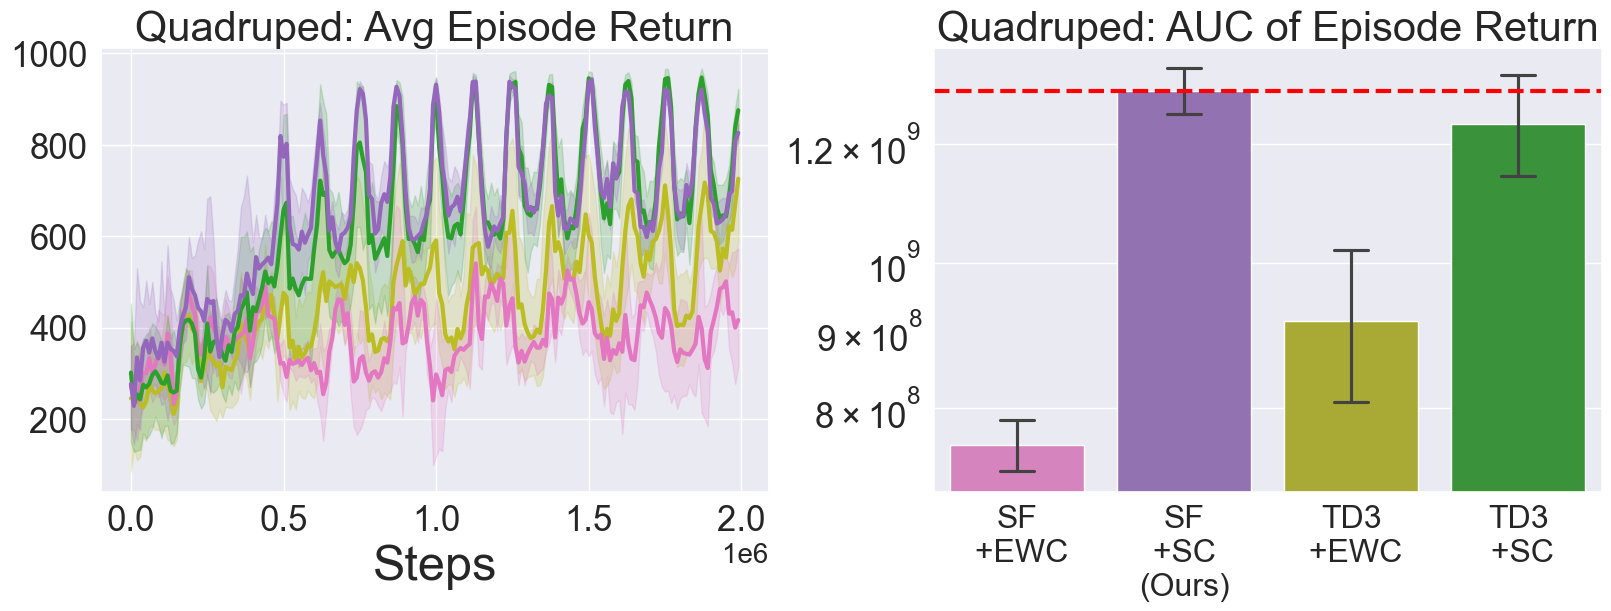

In [30]:
from scipy.integrate import trapezoid
from matplotlib.ticker import MaxNLocator, LogLocator

# Comparing with EWC
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# LEFT
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
#     label=agents_new_names["sf_simple"],
#     color=color_code[agents_new_names["sf_simple"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label=agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"],
#     color=color_code[agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )




# RIGHT

# pick the last row per agent (largest step)
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3 + EWC", "TD3 + SC", "SF + EWC", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "SF + SC (Ours)"]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# for bar, (agent, score) in zip(axes[1].patches, subset[["agent_name","norm_cum_reward"]].values):
#     print(agent)
    # if "SC" in agent:  # only annotate the SC bars
    #     if "TD3" in agent:
    #         base = baselines["TD3"]
    #     elif "SF" in agent:
    #         base = baselines["SF"]
    #
    #     pct_gain = 100 * (score - base) / base
    #     axes[1].text(
    #         bar.get_x() + bar.get_width()/2,
    #         bar.get_height(),
    #         f"+{pct_gain:.1f}%",
    #         ha="center", va="bottom", fontsize=9, fontweight="bold"
    #     )

# fig.suptitle("Multi-timescale Synaptic Consolidation vs Elastic Weight Consolidation (EWC)", fontsize=18)

# axes[0].set_xlabel("", fontsize=14)
# axes[0].set_ylabel("Total Cumulative Return", fontsize=14)
# # axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=18)
# axes[0].set_yscale("log")
#
# # axes[1].set_title("Episode Returns (Evaluation)", fontsize=16)
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="lower left", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=18)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=30)
axes[0].set_xlabel("Steps", fontsize=35)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Quadruped: AUC of Episode Return", fontsize=30)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=25, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=4))
# axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidate_qvals_vs_sf_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_36751/2849723459.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


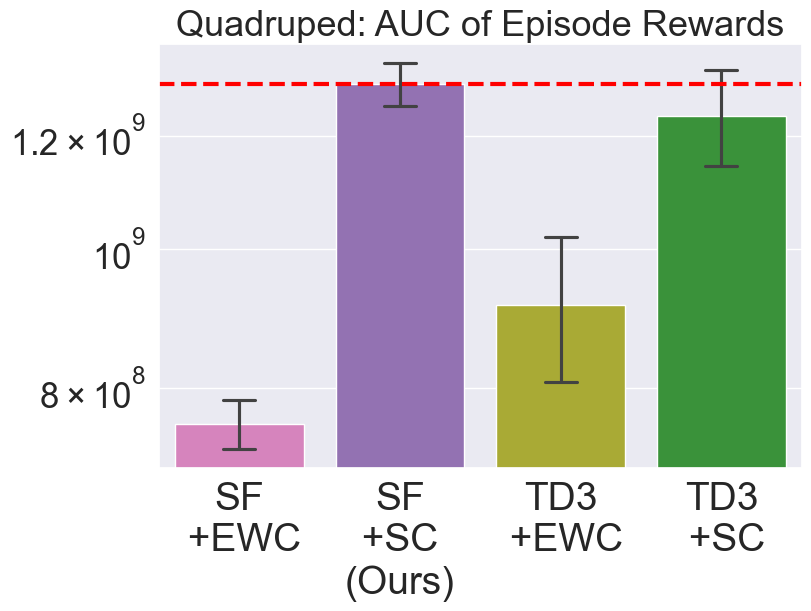

In [31]:
colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3 + EWC", "TD3 + SC", "SF + EWC", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "SF + SC (Ours)"]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

#
# mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
# ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]


# ax = sns.barplot(
#     data=auc_df,
#     x="agent_num_beakers",
#     y="AUC",
#     errorbar="sd",   # std deviation across seeds
#     capsize=0.2,
#     hue="agent_num_beakers",
#     legend=False,
#     palette=colors,
#
# )colors
plt.title("Quadruped: AUC of Episode Rewards", fontsize=26)
plt.ylabel("", fontsize=30)
plt.xlabel("")
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
# ax.set_ylim(7, 9)
plt.yscale("log")
# ax.yaxis.get_offset_text().set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_minor_locator(LogLocator(base=10.0,  numticks=3))     # no minor ticks
ax.tick_params(axis="y", labelsize=25, which="both")
# ax.yaxis.get_offset_text().set_visible(False)
filename = "qvals_sf_ewc_sc_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

['SF', 'SF\n +SC \n(Ours)', 'TD3', 'TD3\n +SC']
Categories (4, object): ['TD3' < 'TD3\n +SC' < 'SF' < 'SF\n +SC \n(Ours)']


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_36751/2909601057.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_36751/2909601057.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_36751/2909601057.py:72: SettingWi

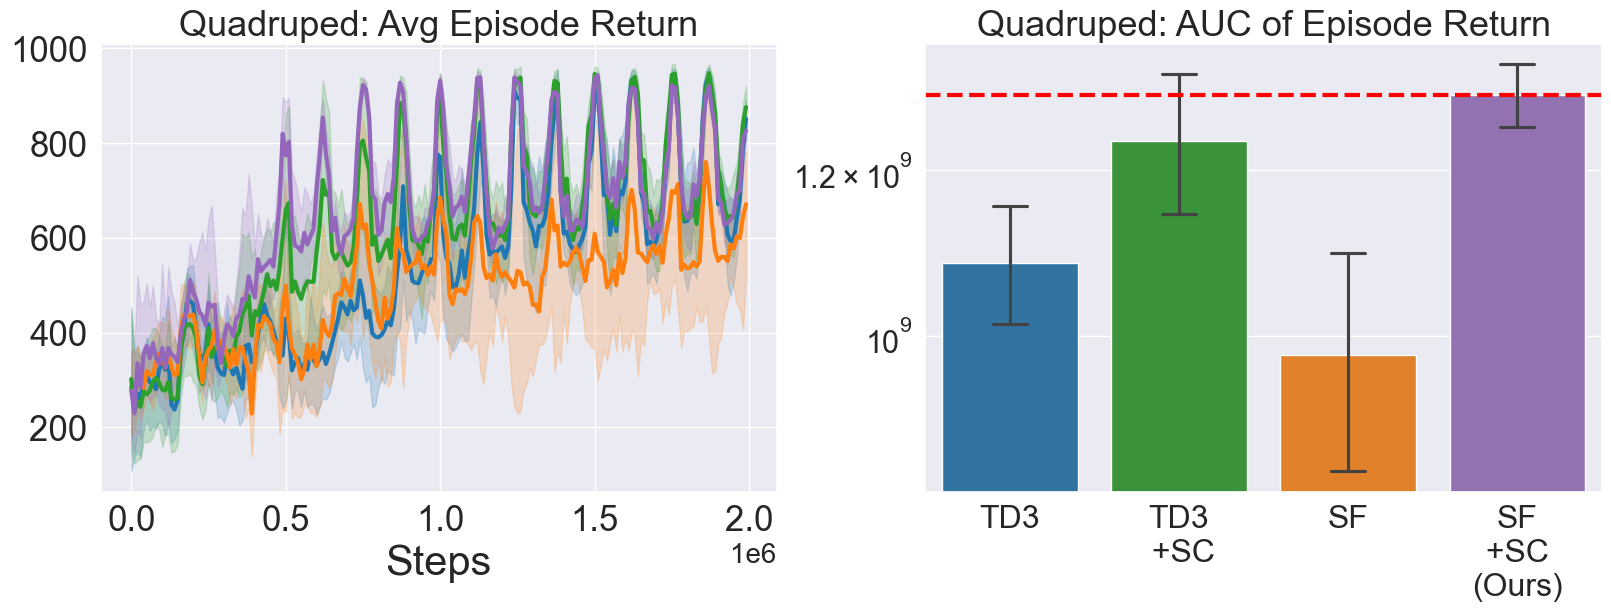

In [33]:
# plot is it better to consolidate parameters of Q-values or SFs?

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

agents_to_plot = ["TD3", "TD3 + SC", "SF", "SF + SC (Ours)",]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"


# Ensure subset has the pretty labels and exact category order
# subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n + SC \n(Ours)"

subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
print(subset["agent_name_pretty"].unique())

ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="lower right", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Quadruped: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidate_qvals_sf_analysis_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3469638753.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3469638753.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3469638753.py:24: SettingWi

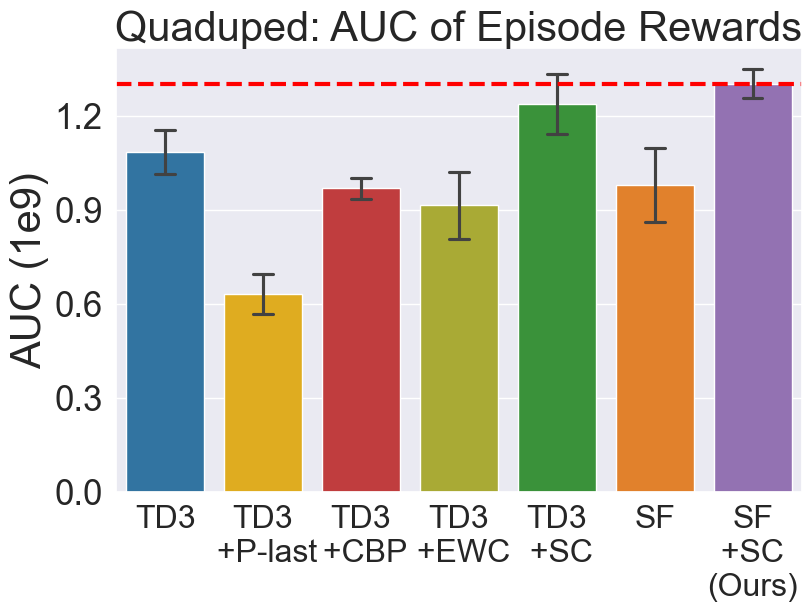

In [31]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]


# ax = sns.barplot(
#     data=auc_df,
#     x="agent_num_beakers",
#     y="AUC",
#     errorbar="sd",   # std deviation across seeds
#     capsize=0.2,
#     hue="agent_num_beakers",
#     legend=False,
#     palette=colors,
#
# )colors
plt.title("Quaduped: AUC of Episode Rewards", fontsize=30)
plt.ylabel("AUC (1e9)", fontsize=30)
plt.xlabel("")
plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.get_offset_text().set_fontsize(20)
ax.yaxis.get_offset_text().set_visible(False)
filename = "plasticity_stability_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

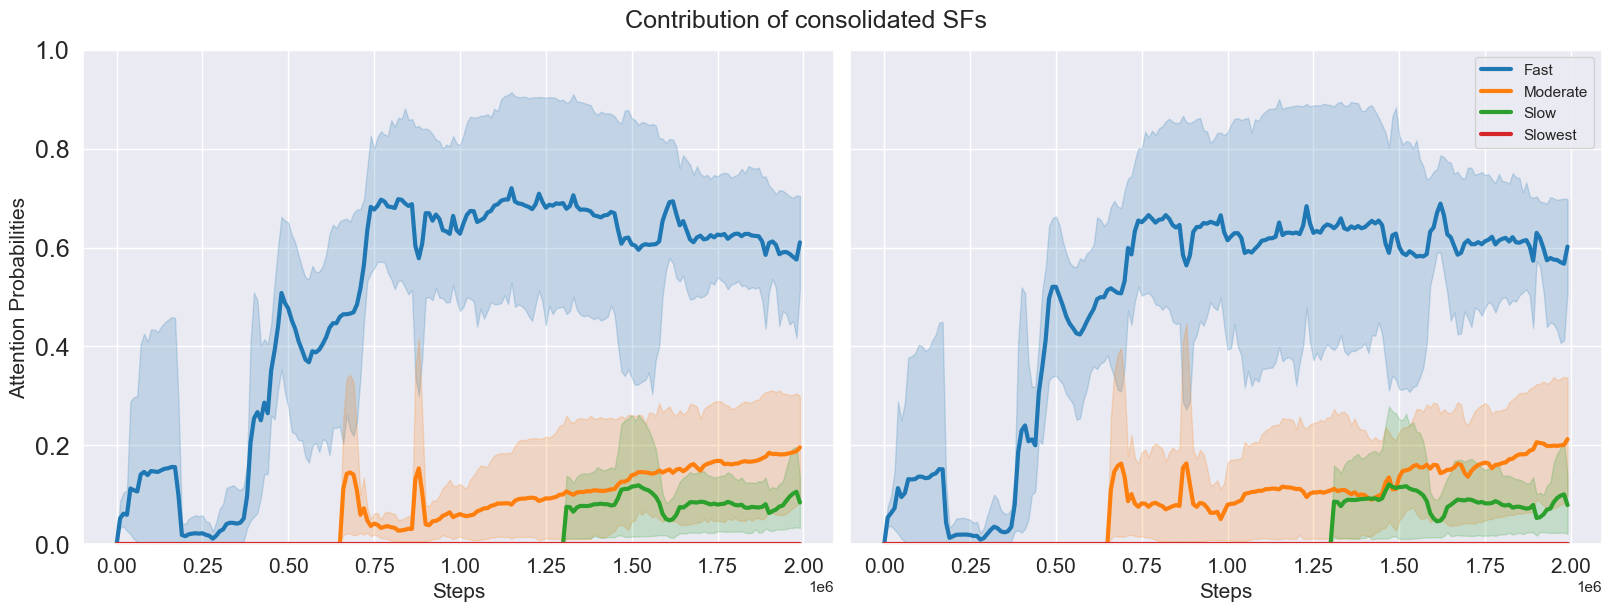

In [32]:
# Understanding the attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True, sharey=True)

colors_attention = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#17BECF"]

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fast",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Moderate",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slow",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slowest",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )



# RIGHT
sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fast",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Moderate",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slow",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slowest",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )

fig.suptitle("Contribution of consolidated SFs", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=15)
axes[0].set_ylabel("Attention Probabilities", fontsize=15)
# axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
axes[0].tick_params(axis="x", labelsize=15)
axes[0].tick_params(axis="y", labelsize=18)
# Set y-axis limits for each subplot
axes[0].set_ylim(0, 1.0)  # Set y-axis limits for the first subplot


axes[1].set_xlabel("Steps", fontsize=15)
axes[1].tick_params(axis="x", labelsize=15)

# # axes[1].set_title("Episode Returns (Evaluation)", fontsize=16)
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="upper right", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=18)
# axes[1].set_ylim(0, 1.0)  # Set y-axis limits for the second subplot

filename = "sf_attention_dist_both_sets" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


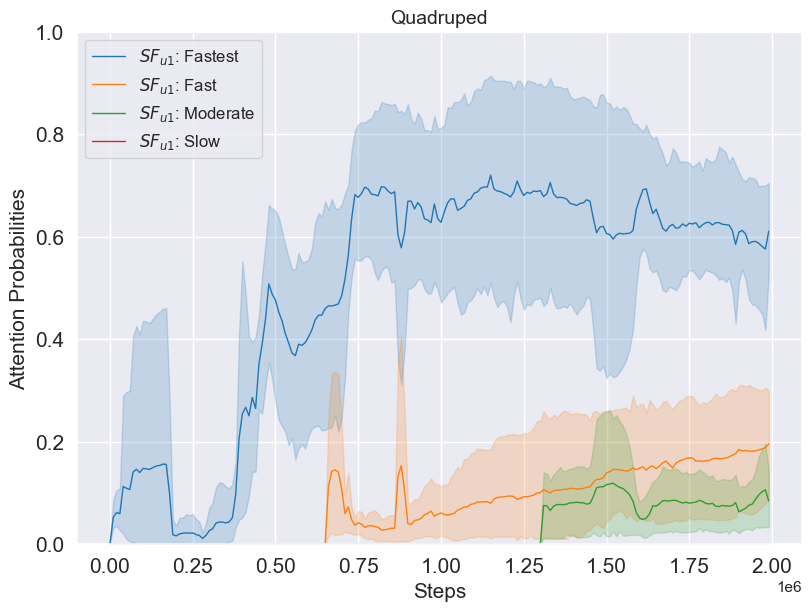

In [33]:
# Analysing the first attention mechanism
f, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$: Fastest",
    color=colors_attention[0],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$: Fast",
    color=colors_attention[1],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$: Moderate",
    color=colors_attention[2],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$: Slow",
    color=colors_attention[3],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    legend=False,
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

plt.title("Quadruped", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Attention Probabilities", fontsize=15)
plt.legend(loc="upper left", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0, 1.0)  # Set y-axis limits for the first subplot

filename = "sf_attention_dist_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


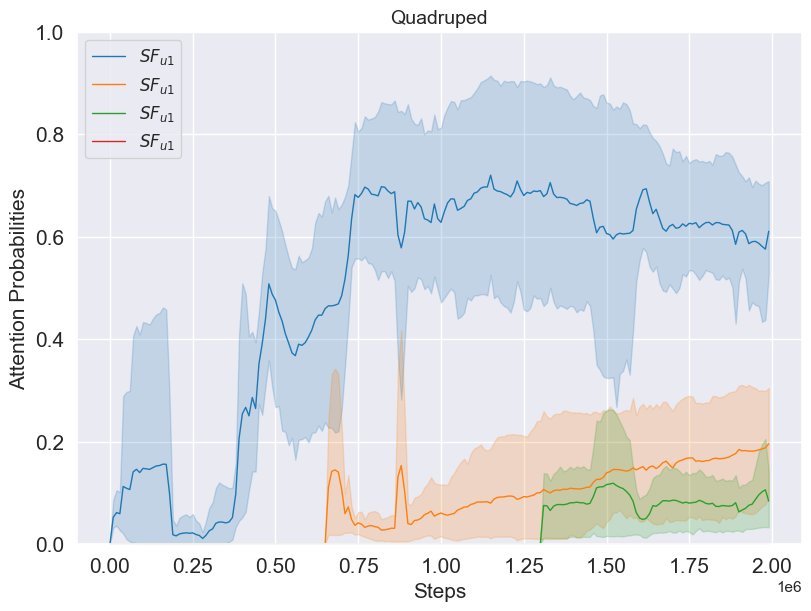

In [34]:
# Analysing the first attention mechanism
f, ax = plt.subplots(figsize=(8, 6), constrained_layout=True,)

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$",
    color=colors_attention[0],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$",
    color=colors_attention[1],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$",
    color=colors_attention[2],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$",
    color=colors_attention[3],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    legend=False,
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

plt.title("Quadruped", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Attention Probabilities", fontsize=15)
plt.legend(loc="upper left", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0, 1.0)  # Set y-axis limits for the first subplot

filename = "sf_attention_dist_without_speed_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [35]:
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

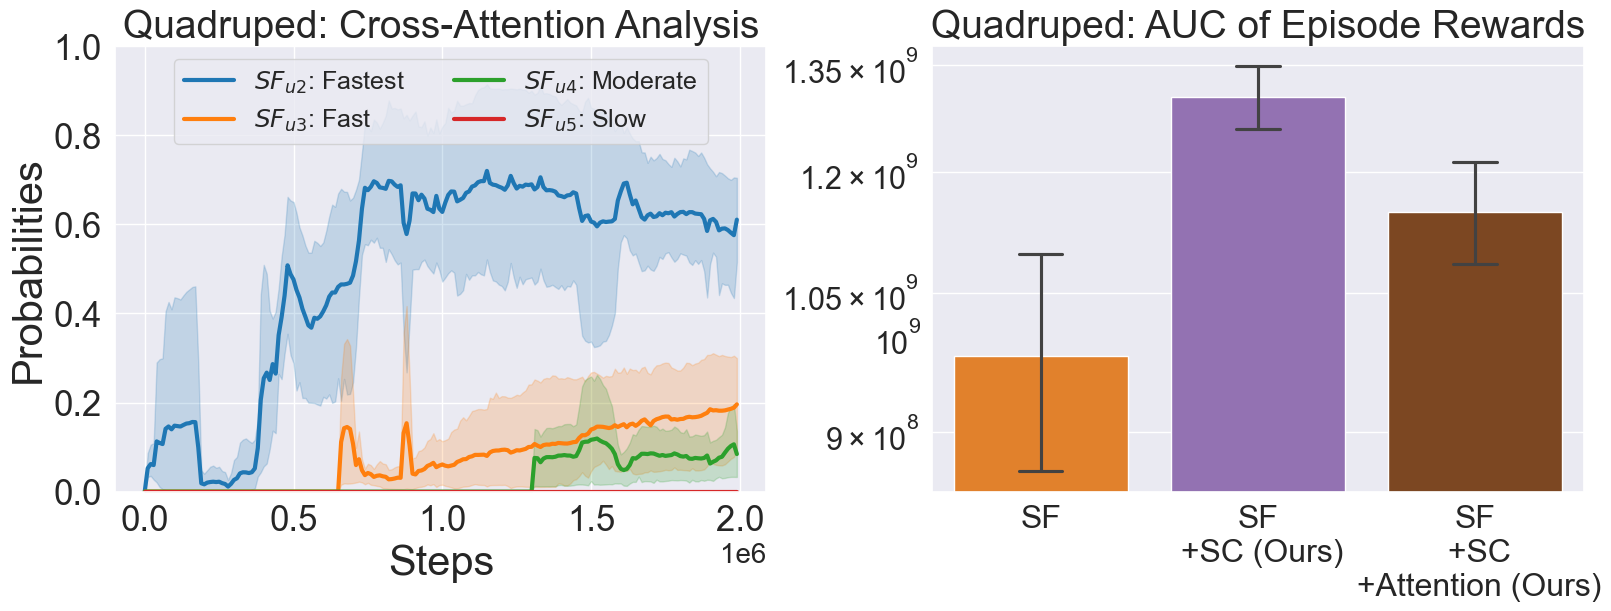

In [36]:
# Understanding the attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors_attention = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#17BECF"]

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u2}$: Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u3}$: Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u4}$: Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u5}$: Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


# RIGHT

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset = subset.copy()
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)

eps = 1e-12  # in case any values are 0
subset = subset.copy()
subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))
sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code,  errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[1])

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("Probabilities", fontsize=30)
axes[0].set_title("Quadruped: Cross-Attention Analysis", fontsize=28)
axes[0].tick_params(axis="x", labelsize=25, which="both")
axes[0].tick_params(axis="y", labelsize=25)
# Set y-axis limits for each subplot
axes[0].set_ylim(0, 1.0)  # Set y-axis limits for the first subplot
axes[0].legend(fontsize=18, loc="upper center", ncol=2, frameon=True)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_title("Quadruped: AUC of Episode Rewards", fontsize=28)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

# plt.subplots_adjust(wspace=0.8)   # increase space between columns

filename = "sf_attention_dist_and_auc_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [37]:
import matplotlib.pyplot as plt
import numpy as np


In [38]:
class NoisySineModulator:
    def __init__(self, period=25000, noise_std=0.05, min_val=0.75, max_val=1.25, phase=0.0, seed=97):
        """
        A noisy sine wave modulator for smooth, periodic scaling values.

        Args:
            period (int): Number of steps per full sine cycle.
            noise_std (float): Standard deviation of Gaussian noise added to sine.
            min_val (float): Minimum value of the scaled output.
            max_val (float): Maximum value of the scaled output.
            phase (float): Phase offset for sine wave (in radians), useful for offsetting mass vs friction.
        """
        self.period = period
        self.noise_std = noise_std
        self.min_val = min_val
        self.max_val = max_val
        self.phase = phase
        self.rng = np.random.default_rng(seed)

    def sample(self, step: int):
        """Return modulated value at a given training step."""
        sine_val = 0.5 * (np.sin(2 * np.pi * step / self.period + self.phase) + 1)
        noisy_val = sine_val + self.rng.normal(0.0, self.noise_std)
        noisy_val = np.clip(noisy_val, 0.0, 1.0)
        scaled_val = self.min_val + (self.max_val - self.min_val) * noisy_val
        return scaled_val


In [39]:
# Create modulators with different seeds
mass_mod = NoisySineModulator(period=250000, phase=0.0, seed=1, min_val=1-0.8, max_val=1+0.8)
friction_mod = NoisySineModulator(period=500000, phase=0.0, seed=2, min_val=0.7, max_val=1.3)

In [40]:
# Sample every 10,000 steps
steps = np.arange(0, 2_000_001, 10_000)
mass_vals = [mass_mod.sample(step) for step in steps]
friction_vals = [friction_mod.sample(step) for step in steps]

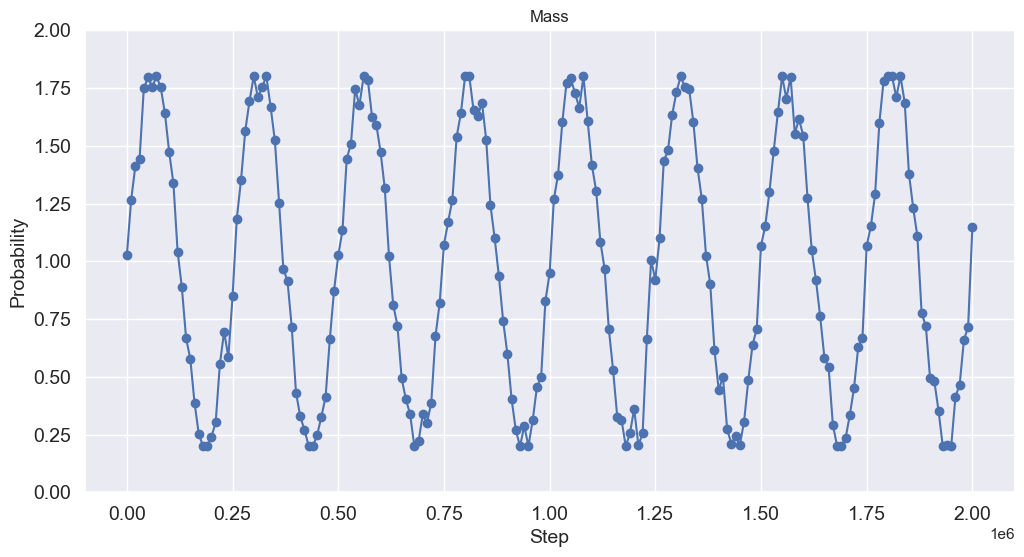

In [41]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(steps, mass_vals, label="Mass Scale", marker='o')
# plt.plot(steps, friction_vals, label="Friction Scale (seed=2)", marker='x')
plt.title("Mass")
plt.xlabel("Step", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0, 2)
# plt.ylim(0.5, 1.5)
# # Save the plot to a file
plt.savefig("mass_dynamics_quadruped.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("sine_wave_plot_friction.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

timescale_summary_list, timescale_config_list, timescale_name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "timescale" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp2 = dict()
    temp2["eval/step"] = steps
    temp2["eval/episode_reward"] = avg_episode_reward

    timescale_summary_list.append(temp2)
    del temp2

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    timescale_config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    timescale_name_list.append(run.name)

num_of_runs: 541
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
idx: 50
idx: 60
idx: 70
idx: 80
idx: 90
idx: 100
idx: 110
idx: 120
idx: 130
idx: 140
idx: 150
idx: 160
idx: 170
idx: 180
idx: 190
idx: 200
idx: 210
idx: 220
idx: 230
idx: 240
idx: 250
idx: 260
idx: 270
idx: 280
idx: 290
idx: 300
idx: 310
idx: 320
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
sf_simple_beakers_params
len(steps):  200
len(avg_episode_reward):  200
idx: 330
sf_simple_beakers_params
len(steps):  20

In [43]:
timescale_runs_df = pd.DataFrame(
        {"summary": timescale_summary_list, "config": timescale_config_list, "name": timescale_name_list}
    )

# create a new column using agent_name
timescale_runs_df["agent_name"] = timescale_runs_df["config"].apply(lambda x: x["agent_name"])

# create a new column using agents_seed
timescale_runs_df["agent_seed"] = timescale_runs_df["config"].apply(lambda x: x["seed"])


# create a new column using agent_num_beakers
timescale_runs_df["agent_num_beakers"] = timescale_runs_df["config"].apply(lambda x: x["agent_num_beakers"])

In [44]:
# replace all "ddpg" in agent_name column with "TD3"
timescale_runs_df["agent_name"] = timescale_runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [45]:
print(timescale_runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed', 'agent_num_beakers']


In [46]:
# remove the name and config column
timescale_runs_df = timescale_runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
timescale_runs_df = pd.concat(
    [timescale_runs_df.drop(["summary"], axis=1), timescale_runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
timescale_runs_df = timescale_runs_df.reset_index(drop=True)

print(timescale_runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
timescale_runs_df = timescale_runs_df.explode(list(timescale_runs_df.columns[3:])).reset_index(drop=True)

print(timescale_runs_df.shape)

print("dataframe: ", timescale_runs_df)

        agent_name  agent_seed  agent_num_beakers  \
0   SF + SC (Ours)         388                  8   
1   SF + SC (Ours)         485                  8   
2   SF + SC (Ours)          97                  8   
3   SF + SC (Ours)         582                  8   
4   SF + SC (Ours)         291                  8   
5   SF + SC (Ours)         679                  8   
6   SF + SC (Ours)         194                  8   
7   SF + SC (Ours)         291                  6   
8   SF + SC (Ours)         582                  6   
9   SF + SC (Ours)         194                  6   
10  SF + SC (Ours)         485                  6   
11  SF + SC (Ours)         388                  6   
12  SF + SC (Ours)          97                  6   
13  SF + SC (Ours)         582                  3   
14  SF + SC (Ours)         194                  3   
15  SF + SC (Ours)         485                  3   
16  SF + SC (Ours)         388                  3   
17  SF + SC (Ours)          97                

In [47]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(timescale_runs_df.columns)

timescale_runs_df["eval/episode_rewards_num"] = (
    timescale_runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

timescale_runs_df = timescale_runs_df.sort_values(["agent_num_beakers", "agent_seed","eval/step"])

timescale_runs_df["eval/cumulative_rewards"] = (
    timescale_runs_df.groupby(["agent_num_beakers","agent_seed"])["eval/episode_rewards_num"].cumsum()
)

timescale_runs_df["episode_count"] = (
    timescale_runs_df.groupby(["agent_num_beakers","agent_seed", ]).cumcount() + 1
)

timescale_runs_df["norm_cum_reward"] = timescale_runs_df["eval/cumulative_rewards"] / timescale_runs_df["episode_count"]

timescale_runs_df["agent_name_pretty"] = timescale_runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(timescale_runs_df.columns)
# print(timescale_runs_df["agent_num_beakers","norm_cum_reward"])

Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/step',
       'eval/episode_reward'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/step',
       'eval/episode_reward', 'eval/episode_rewards_num',
       'eval/cumulative_rewards', 'episode_count', 'norm_cum_reward',
       'agent_name_pretty'],
      dtype='object')


In [48]:
runs_df_sf_simple = runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]]

runs_df_sf_simple = runs_df_sf_simple[["agent_name", "agent_seed", "eval/step", "eval/episode_reward", "eval/cumulative_rewards", "episode_count", "norm_cum_reward", "agent_name_pretty", "eval/episode_rewards_num"]]

runs_df_sf_simple["agent_num_beakers"] = 0

timescale_runs_df = pd.concat([timescale_runs_df, runs_df_sf_simple], ignore_index=True)

print(timescale_runs_df)

          agent_name  agent_seed  agent_num_beakers  eval/step  \
0     SF + SC (Ours)          97                  3          0   
1     SF + SC (Ours)          97                  3      10000   
2     SF + SC (Ours)          97                  3      20000   
3     SF + SC (Ours)          97                  3      30000   
4     SF + SC (Ours)          97                  3      40000   
...              ...         ...                ...        ...   
4595              SF         485                  0  1950000.0   
4596              SF         485                  0  1960000.0   
4597              SF         485                  0  1970000.0   
4598              SF         485                  0  1980000.0   
4599              SF         485                  0  1990000.0   

     eval/episode_reward  eval/episode_rewards_num  eval/cumulative_rewards  \
0              369.47827                369.478270               369.478270   
1             378.733825                378.73382

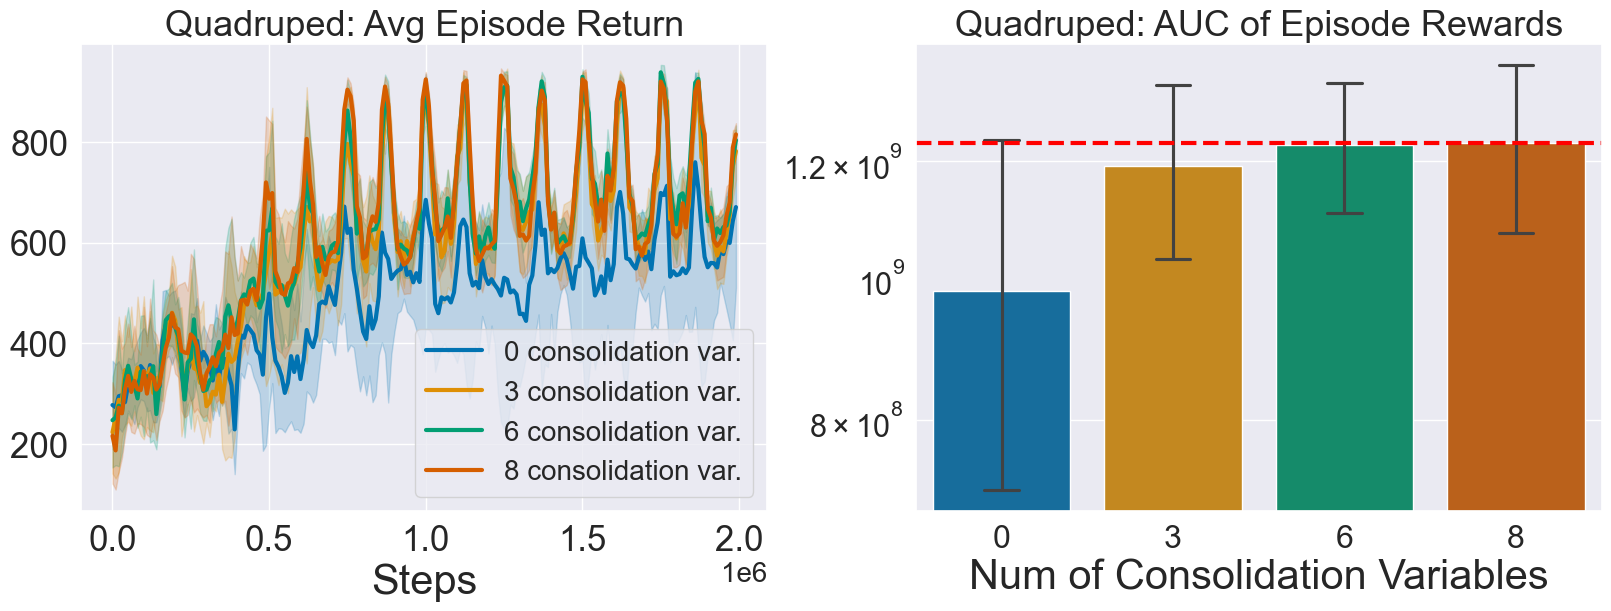

In [49]:
# Comparing with different number of beakers
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label="0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 8],
    label= "8 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# RIGHT
# pick the last row per agent (largest step)
# RIGHT
# pick the last row per agent (largest step)
auc_df = (
    timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

sns.barplot(
    data=auc_df,
    x="agent_num_beakers",
    y="AUC",
    errorbar="sd",   # std deviation across seeds
    capsize=0.2,
    hue="agent_num_beakers",
    palette=colors,
    ax=axes[1],
    legend=False,
)

mean_val = auc_df[auc_df["agent_num_beakers"] == 8]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="lower right", fontsize=20)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("Num of Consolidation Variables", fontsize=30)
axes[1].set_ylabel("", fontsize=30)
axes[1].set_title("Quadruped: AUC of Episode Rewards", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=2))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "num_beakers_analysis_with_auc_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


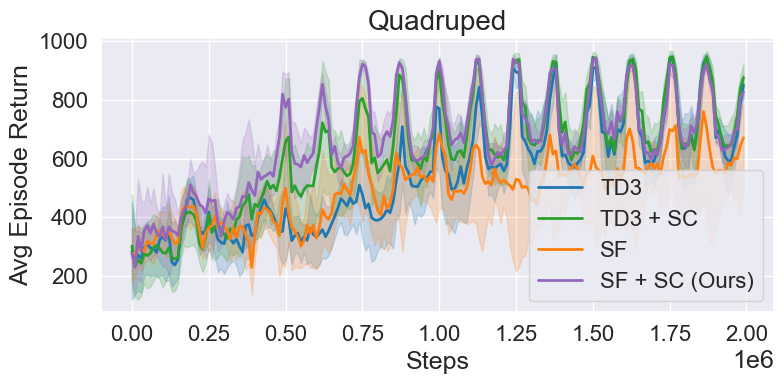

In [50]:


# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.figure(figsize=(8,4))

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("Quadruped", fontsize=20)
plt.ylabel("Avg Episode Return", fontsize=18)
plt.xlabel("Steps", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
plt.tight_layout()
plt.legend(loc="lower right", fontsize=16)
filename = "q_sc_vs_sf_sc_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

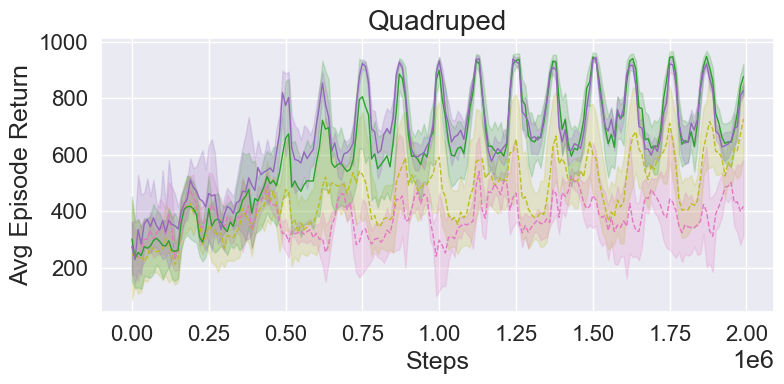

In [51]:


# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.figure(figsize=(8,4))


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("Quadruped", fontsize=20)
plt.ylabel("Avg Episode Return", fontsize=18)
plt.xlabel("Steps", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.get_offset_text().set_fontsize(18)
plt.tight_layout()
plt.legend([], [], frameon=False)

filename = "ewc_vs_sc_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

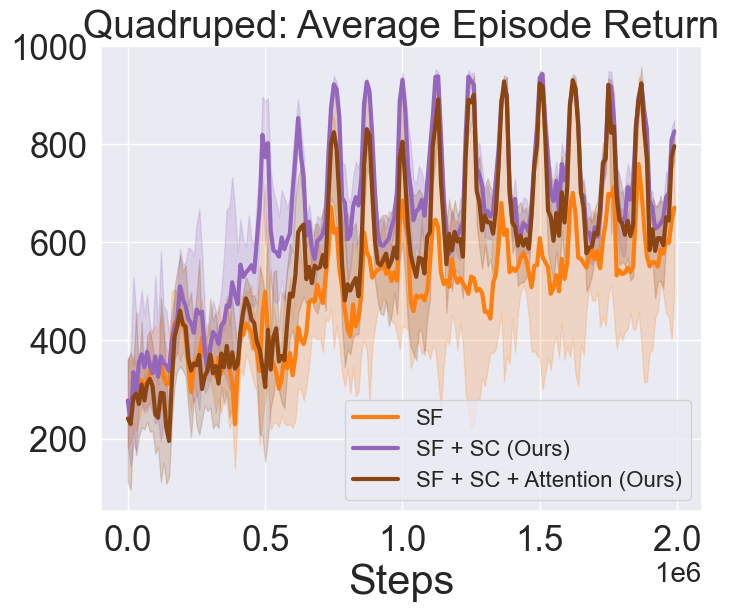

In [52]:
# Using attention to improve memory recall
plt.figure(figsize=(7, 6), constrained_layout=True)

# RIGHT
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#




# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
#     label=agents_new_names["ddpg_beakers_params_continuous"],
#     color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"],
    color=color_code[agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

# fig.suptitle("Can cross-attention improve memory recall?", fontsize=18)

# axes[0].set_xlabel("Agent", fontsize=14)
# axes[0].set_ylabel("Total Cumulative Return", fontsize=14)
# # axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=18)
# axes[0].set_yscale("log")

plt.title("Quadruped: Average Episode Return", fontsize=28)
plt.ylabel("", fontsize=14)
plt.xlabel("Steps", fontsize=30)
plt.legend(loc="lower right", fontsize=16)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.gca().xaxis.get_offset_text().set_fontsize(20)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "avg_episode_reward_attention_sf_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


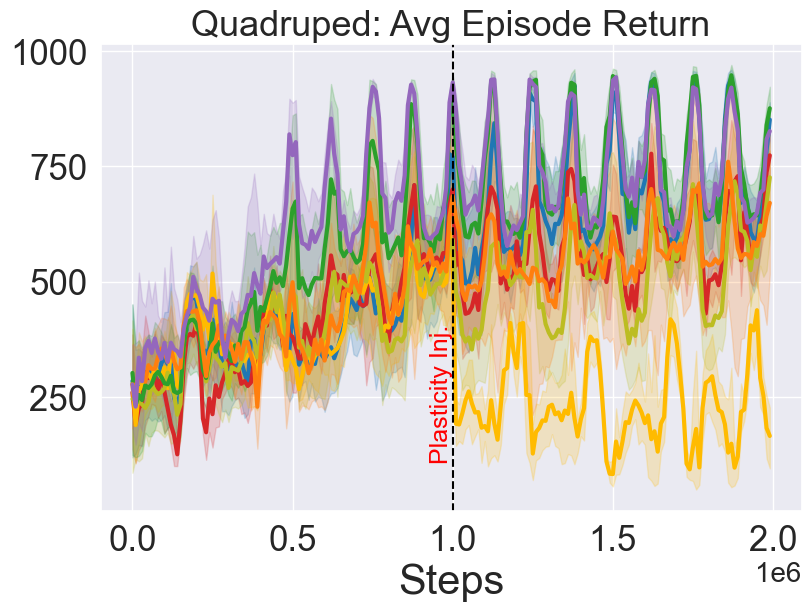

In [53]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator
plt.close()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

xline = 1e6
ymin, ymax = ax.get_ylim()

ax.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
ax.text(
    xline,                      # x position (same as line)
    ymin + 0.4* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)

plt.title("Quadruped: Avg Episode Return", fontsize=26)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("", fontsize=30)
# plt.legend(loc="lower right", fontsize=16, ncol=1)
plt.legend().set_visible(False)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.xaxis.get_offset_text().set_fontsize(20)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "synaptic_consolidation_with_sf_avg_episode_return_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()


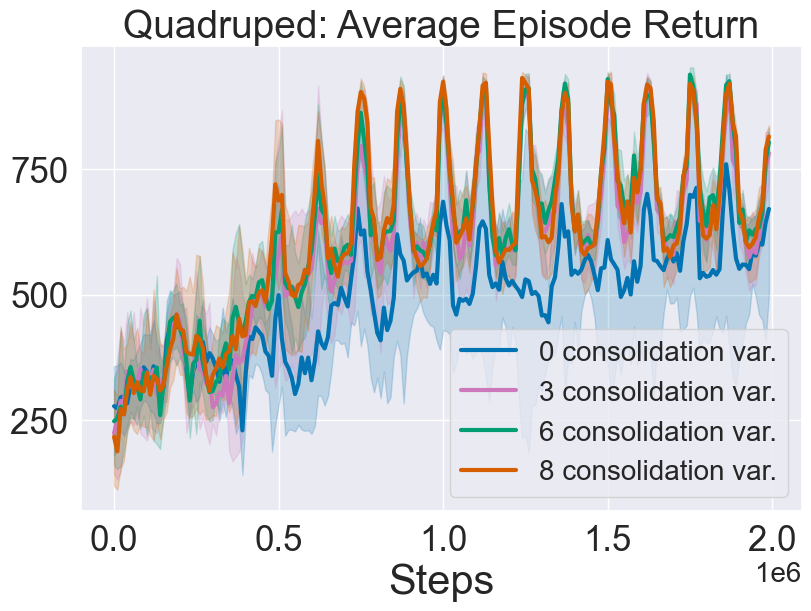

In [54]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 6)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.close()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 0],
    label= "0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[4],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 8],
    label= "8 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)
# ax.set_yscale("log")
plt.title("Quadruped: Average Episode Return", fontsize=28)
plt.ylabel("", fontsize=14)
plt.xlabel("Steps", fontsize=30)
plt.legend(loc="lower right", fontsize=20)
# plt.legend().set_visible(False)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.gca().xaxis.get_offset_text().set_fontsize(20)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=4))


filename = "num_beakers_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3669804654.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3669804654.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/3669804654.py:114: Settin

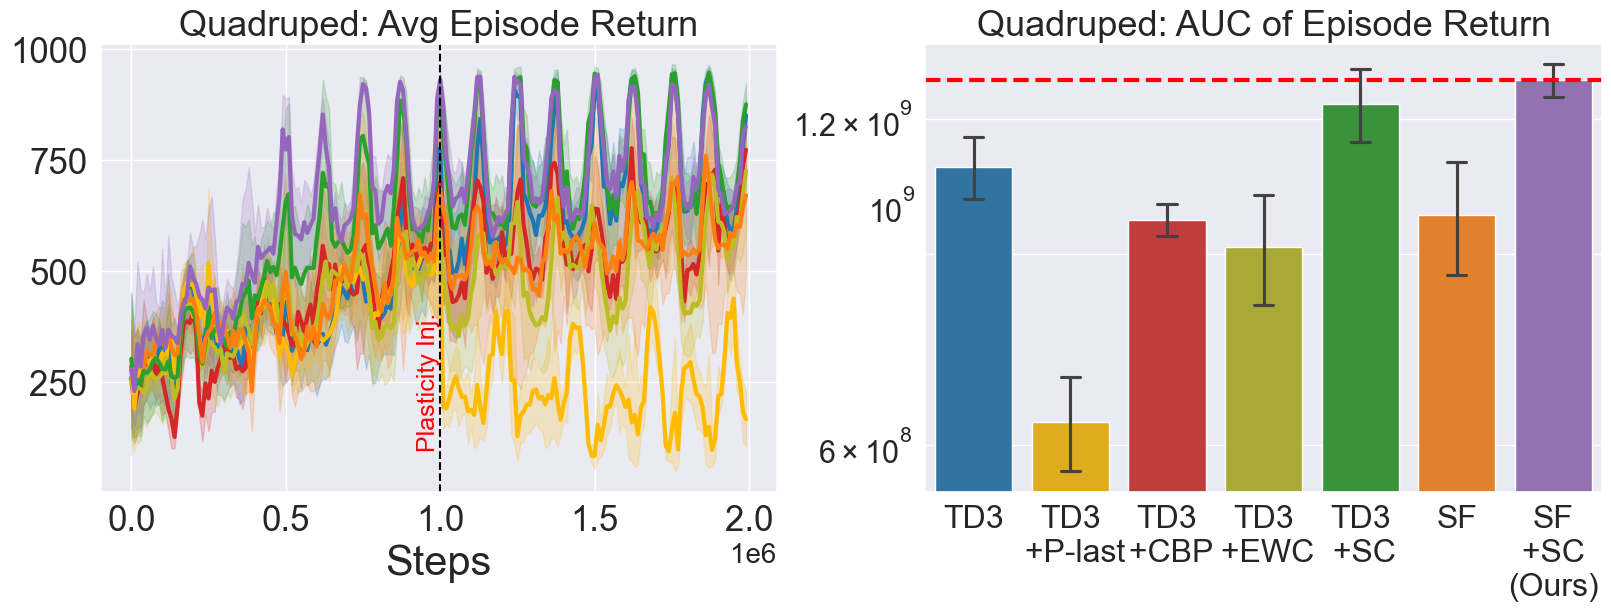

In [59]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

xline = 1000000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)

ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=16, ncol=2)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=12)
axes[1].set_ylabel("", fontsize=20)
axes[1].set_title("Quadruped: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].yaxis.get_offset_text().set_visible(False)

filename = "plasticity_stability_analysis_with_sf_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_17768/2741826497.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


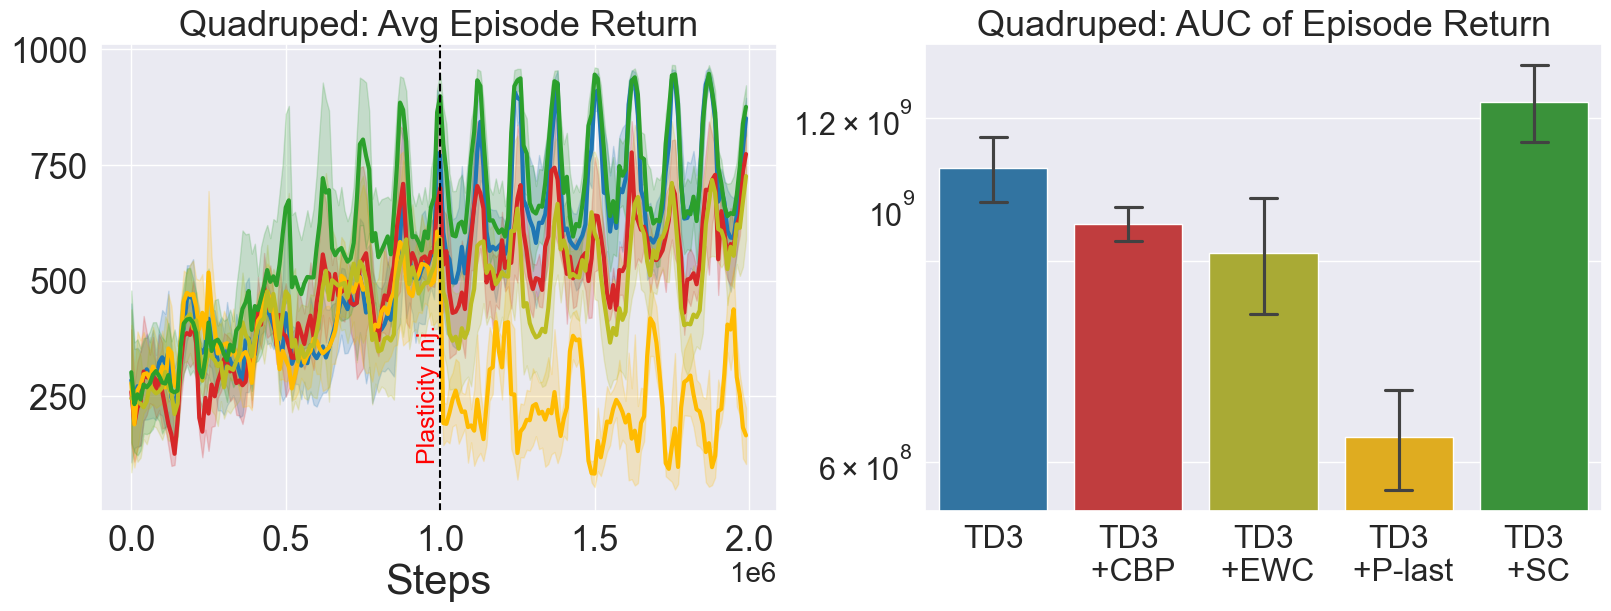

In [56]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
#     label=agents_new_names["sf_simple_beakers_params"],
#     color=color_code[agents_new_names["sf_simple_beakers_params"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )

xline = 1000000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Quadruped: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=16, ncol=2)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=26)
axes[1].set_title("Quadruped: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].yaxis.get_offset_text().set_visible(False)

filename = "plasticity_stability_analysis_with_only_qvals_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()
